# Phase 3 — Modélisation Multi-Algorithmes

### Objectifs
1. Entraîner 3 modèles (LogReg baseline, Random Forest, Gradient Boosting)
2. Gérer le déséquilibre des classes (class_weight, SMOTE, ajustement du seuil)
3. Comparer rigoureusement les performances (métriques, CV, courbes ROC/PR)
4. Interpréter le modèle final (Feature Importance, SHAP)
5. Sérialiser le modèle final dans `artifacts/`

**Dépendance** : le module `backend.data.preprocessing` (Tâche A).

In [1]:
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

sys.path.insert(0, os.path.abspath('..'))

from backend.data.preprocessing import (
    load_and_split, build_preprocessor, get_feature_names,
    NUM_COLS, CAT_COLS_ONEHOT, CAT_COLS_ORDINAL, ENGINEERED_COLS,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, roc_auc_score,
    average_precision_score, precision_score, recall_score, accuracy_score,
    roc_curve, precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from imblearn.over_sampling import SMOTE

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)

FIGURES_DIR   = '../reports/figures/'
ARTIFACTS_DIR = '../artifacts/'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Chargement et preprocessing

In [2]:
X_train, X_test, y_train, y_test = load_and_split('../customer_churn.csv')
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)
feature_names = get_feature_names(preprocessor)

ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f'Ratio déséquilibre : {ratio:.1f}:1')
print(f'Features après encoding : {len(feature_names)}')

Train : (8000, 33) | Churn rate: 10.2%
Test  : (2000, 33)  | Churn rate: 10.2%
Ratio déséquilibre : 8.8:1
Features après encoding : 57


## 2. Gestion du déséquilibre — SMOTE

Le dataset est fortement déséquilibré (≈9:1). Deux stratégies :
- **class_weight='balanced'** : pénalise davantage les erreurs sur la classe minoritaire
- **SMOTE** : génère des exemples synthétiques de churners pour équilibrer le train set

On compare les deux approches. SMOTE est appliqué **uniquement sur le train** (pas le test).

In [3]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train_t, y_train)

print(f'Avant SMOTE : {X_train_t.shape[0]} samples, churn rate = {y_train.mean():.1%}')
print(f'Après SMOTE : {X_train_sm.shape[0]} samples, churn rate = {y_train_sm.mean():.1%}')

Avant SMOTE : 8000 samples, churn rate = 10.2%
Après SMOTE : 14366 samples, churn rate = 50.0%


## 3. Entraînement des 3 modèles

| # | Modèle | Stratégie déséquilibre | Justification |
|---|--------|------------------------|---------------|
| 1 | Logistic Regression | class_weight=balanced | Baseline simple et interprétable |
| 2 | Random Forest | SMOTE | Ensemble non-linéaire, capte les interactions |
| 3 | Gradient Boosting | SMOTE | Boosting séquentiel, souvent top sur tabulaire |
| 4 | MLP (Deep Learning) | SMOTE | Capte les interactions complexes entre features |

In [4]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
        'train_X': X_train_t, 'train_y': y_train,
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'train_X': X_train_sm, 'train_y': y_train_sm,
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=0.8, random_state=RANDOM_STATE),
        'train_X': X_train_sm, 'train_y': y_train_sm,
    },
}

results = {}

for name, cfg in models.items():
    print(f'--- {name} ---')
    m = cfg['model']
    m.fit(cfg['train_X'], cfg['train_y'])
    
    y_pred  = m.predict(X_test_t)
    y_proba = m.predict_proba(X_test_t)[:, 1]
    
    results[name] = {
        'model': m,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'pr_auc':    average_precision_score(y_test, y_proba),
    }
    
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.94      0.68      0.79      1796
           1       0.19      0.65      0.29       204

    accuracy                           0.68      2000
   macro avg       0.57      0.66      0.54      2000
weighted avg       0.87      0.68      0.74      2000


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.94      1796
           1       0.00      0.00      0.00       204

    accuracy                           0.90      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.81      0.90      0.85      2000


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1796
           1       0.23      0.05      0.09       204

    accuracy                           0.89      2000
   macro avg       0.57      0.52      0.51      2

## 4. Tableau comparatif

In [5]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ('model', 'y_pred', 'y_proba')}
    for name, r in results.items()
}).T.round(3)

print('Tableau comparatif des métriques :')
metrics_df

Tableau comparatif des métriques :


,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.678,0.188,0.647,0.291,0.730,0.242
Random Forest,0.895,0.000,0.000,0.000,0.792,0.257
Gradient Boosting,0.886,0.234,0.054,0.088,0.796,0.271


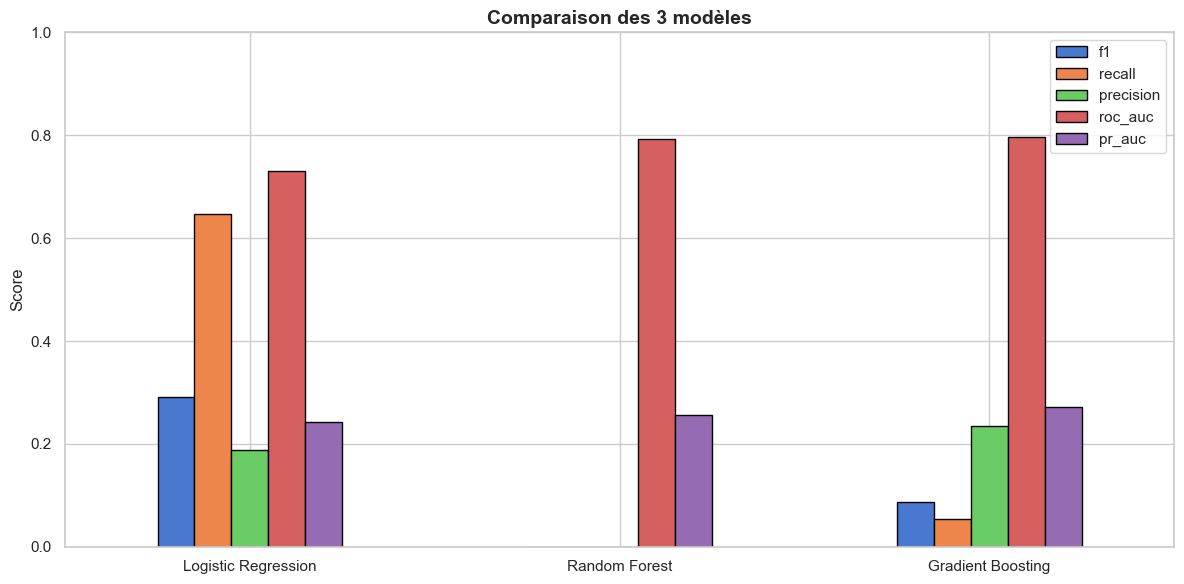

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
metrics_plot = metrics_df[['f1', 'recall', 'precision', 'roc_auc', 'pr_auc']]
metrics_plot.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Comparaison des 3 modèles', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}model_comparison.png', bbox_inches='tight')
plt.show()

## 5. Courbes ROC et Precision-Recall

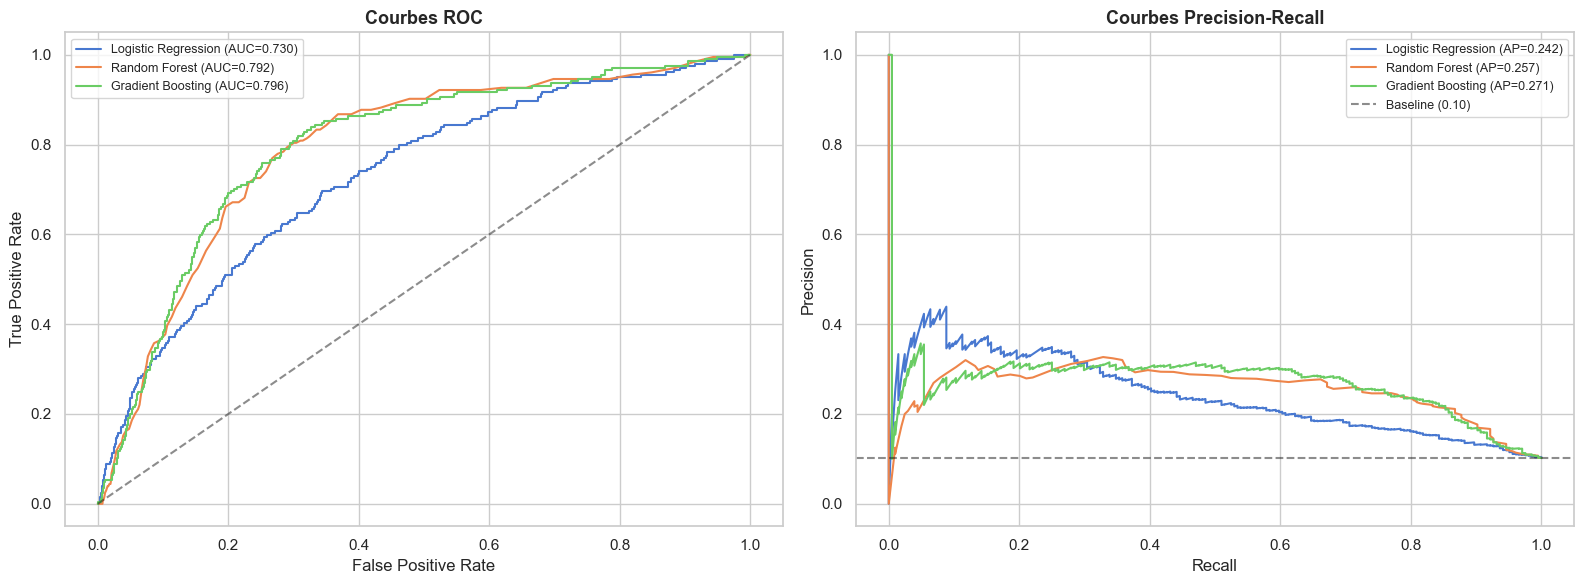

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, r in results.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
    
    # PR
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, r['y_proba'])
    ax2.plot(rec_curve, prec_curve, label=f"{name} (AP={r['pr_auc']:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Courbes ROC', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2.axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Courbes Precision-Recall', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 6. Cross-validation stratifiée (5-fold)

Vérifie la stabilité des modèles — un modèle avec un écart-type élevé en CV est instable.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, cfg in models.items():
    m_fresh = cfg['model'].__class__(**cfg['model'].get_params())
    cv_f1  = cross_val_score(m_fresh, cfg['train_X'], cfg['train_y'], cv=cv, scoring='f1')
    cv_roc = cross_val_score(m_fresh, cfg['train_X'], cfg['train_y'], cv=cv, scoring='roc_auc')
    cv_results[name] = {
        'cv_f1_mean': cv_f1.mean(), 'cv_f1_std': cv_f1.std(),
        'cv_roc_mean': cv_roc.mean(), 'cv_roc_std': cv_roc.std(),
    }
    print(f'{name:25s}  CV-F1={cv_f1.mean():.3f}±{cv_f1.std():.3f}  CV-ROC={cv_roc.mean():.3f}±{cv_roc.std():.3f}')

cv_df = pd.DataFrame(cv_results).T.round(3)
cv_df

Logistic Regression        CV-F1=0.303±0.013  CV-ROC=0.732±0.017
Random Forest              CV-F1=0.951±0.003  CV-ROC=0.990±0.001
Gradient Boosting          CV-F1=0.939±0.002  CV-ROC=0.980±0.001


,cv_f1_mean,cv_f1_std,cv_roc_mean,cv_roc_std
Logistic Regression,0.303,0.013,0.732,0.017
Random Forest,0.951,0.003,0.990,0.001
Gradient Boosting,0.939,0.002,0.980,0.001


## 7. Ajustement du seuil de décision

Le seuil par défaut (0.5) n'est pas optimal pour un dataset déséquilibré.
On teste différents seuils pour maximiser le F1 tout en gardant un Recall élevé.

On teste sur les **deux meilleurs modèles** (ceux avec le meilleur ROC-AUC).

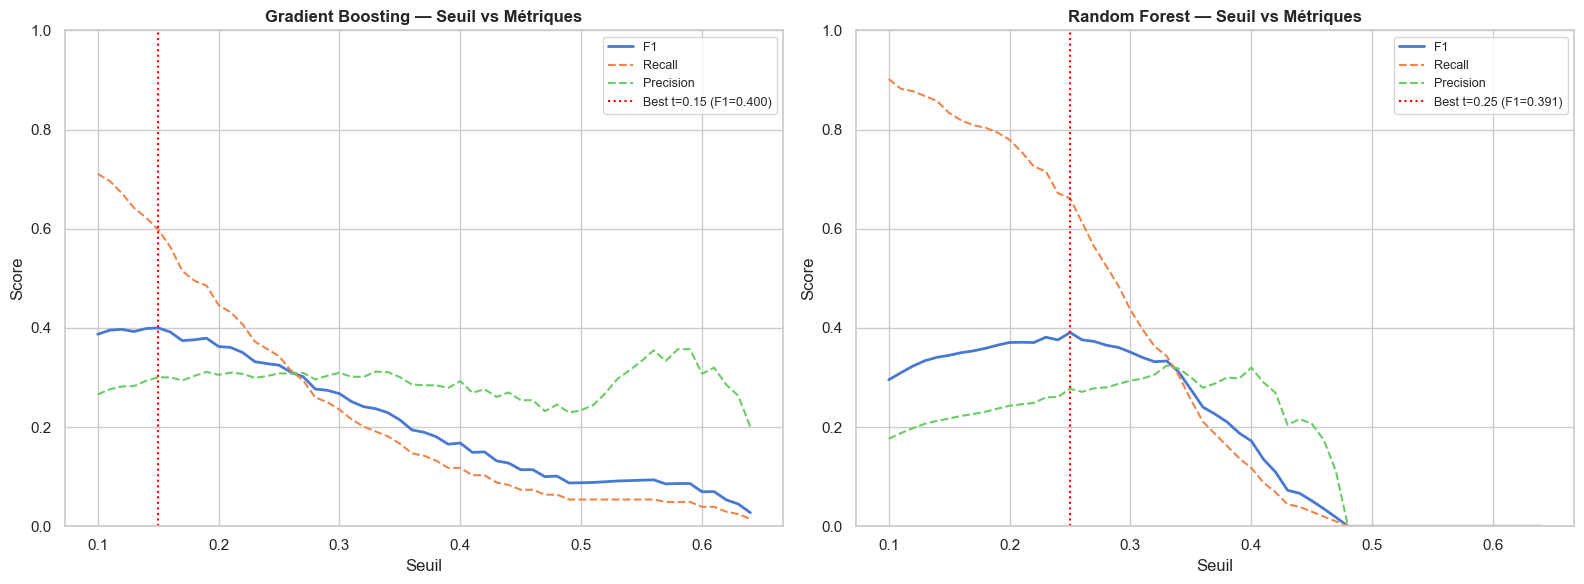

Gradient Boosting: seuil optimal = 0.15, F1 = 0.400
Random Forest: seuil optimal = 0.25, F1 = 0.391


In [9]:
# Identifier les 2 meilleurs modèles par ROC-AUC
top2 = sorted(results.items(), key=lambda x: -x[1]['roc_auc'])[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
best_configs = {}

for idx, (name, r) in enumerate(top2):
    thresholds = np.arange(0.10, 0.65, 0.01)
    f1s, recs, precs = [], [], []
    
    for t in thresholds:
        yp = (r['y_proba'] >= t).astype(int)
        f1s.append(f1_score(y_test, yp, zero_division=0))
        recs.append(recall_score(y_test, yp, zero_division=0))
        precs.append(precision_score(y_test, yp, zero_division=0))
    
    best_idx = np.argmax(f1s)
    best_t = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_configs[name] = {'threshold': float(best_t), 'f1': float(best_f1)}
    
    ax = axes[idx]
    ax.plot(thresholds, f1s, label='F1', linewidth=2)
    ax.plot(thresholds, recs, label='Recall', linestyle='--')
    ax.plot(thresholds, precs, label='Precision', linestyle='--')
    ax.axvline(x=best_t, color='red', linestyle=':', label=f'Best t={best_t:.2f} (F1={best_f1:.3f})')
    ax.set_xlabel('Seuil')
    ax.set_ylabel('Score')
    ax.set_title(f'{name} — Seuil vs Métriques', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}threshold_tuning.png', bbox_inches='tight')
plt.show()

for name, cfg in best_configs.items():
    print(f"{name}: seuil optimal = {cfg['threshold']:.2f}, F1 = {cfg['f1']:.3f}")

## 8. Comparaison des techniques de gestion du déséquilibre

On compare 3 approches sur le meilleur modèle :
1. Sans traitement (baseline)
2. class_weight='balanced'
3. SMOTE + seuil optimal

In [10]:
# On prend Gradient Boosting comme base de comparaison
imbalance_results = {}

# 1. Sans traitement
gb_raw = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE)
gb_raw.fit(X_train_t, y_train)
y_pred_raw = gb_raw.predict(X_test_t)
y_proba_raw = gb_raw.predict_proba(X_test_t)[:, 1]
imbalance_results['Sans traitement'] = {
    'recall': recall_score(y_test, y_pred_raw, zero_division=0),
    'f1': f1_score(y_test, y_pred_raw, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_raw),
}

# 2. class_weight via sample_weight heuristic
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight('balanced', y_train)
gb_cw = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE)
gb_cw.fit(X_train_t, y_train, sample_weight=sw)
y_pred_cw = gb_cw.predict(X_test_t)
y_proba_cw = gb_cw.predict_proba(X_test_t)[:, 1]
imbalance_results['class_weight balanced'] = {
    'recall': recall_score(y_test, y_pred_cw, zero_division=0),
    'f1': f1_score(y_test, y_pred_cw, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_cw),
}

# 3. SMOTE + seuil optimal
gb_best = results['Gradient Boosting']['model']
y_proba_sm = results['Gradient Boosting']['y_proba']
best_t_gb = best_configs.get('Gradient Boosting', {}).get('threshold', 0.5)
y_pred_sm = (y_proba_sm >= best_t_gb).astype(int)
imbalance_results['SMOTE + seuil optimal'] = {
    'recall': recall_score(y_test, y_pred_sm, zero_division=0),
    'f1': f1_score(y_test, y_pred_sm, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_sm),
}

imbalance_df = pd.DataFrame(imbalance_results).T.round(3)
print('Comparaison des techniques de gestion du déséquilibre (Gradient Boosting) :')
imbalance_df

Comparaison des techniques de gestion du déséquilibre (Gradient Boosting) :


,recall,f1,roc_auc
Sans traitement,0.078,0.124,0.772
class_weight balanced,0.260,0.252,0.754
SMOTE + seuil optimal,0.598,0.400,0.796


## 9. Optimisation des hyperparamètres (RandomizedSearchCV)

On optimise le Gradient Boosting (meilleur ROC-AUC + PR-AUC) avec SMOTE.

In [11]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [5, 10, 20],
}

search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_dist,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train_sm, y_train_sm)

print(f'Meilleurs hyperparamètres : {search.best_params_}')
print(f'Meilleur score CV ROC-AUC : {search.best_score_:.3f}')

best_model = search.best_estimator_

Meilleurs hyperparamètres : {'subsample': 0.8, 'n_estimators': 500, 'min_samples_leaf': 20, 'max_depth': 8, 'learning_rate': 0.05}
Meilleur score CV ROC-AUC : 0.984


In [12]:
# Évaluer le modèle optimisé
y_proba_opt = best_model.predict_proba(X_test_t)[:, 1]

# Trouver le seuil optimal pour le modèle optimisé
thresholds = np.arange(0.10, 0.65, 0.01)
f1s = [f1_score(y_test, (y_proba_opt >= t).astype(int), zero_division=0) for t in thresholds]
optimal_threshold = float(thresholds[np.argmax(f1s)])
y_pred_opt = (y_proba_opt >= optimal_threshold).astype(int)

print(f'Seuil optimal du modèle tuné : {optimal_threshold:.2f}')
print(f'\nClassification Report (seuil={optimal_threshold:.2f}) :')
print(classification_report(y_test, y_pred_opt, zero_division=0))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_opt):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_opt):.3f}')

Seuil optimal du modèle tuné : 0.10

Classification Report (seuil=0.10) :
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      1796
           1       0.26      0.41      0.32       204

    accuracy                           0.82      2000
   macro avg       0.59      0.64      0.61      2000
weighted avg       0.86      0.82      0.84      2000

ROC-AUC : 0.773
PR-AUC  : 0.235


## 10. Analyse des erreurs

Examen des faux négatifs (churners manqués) et faux positifs (fausses alertes).

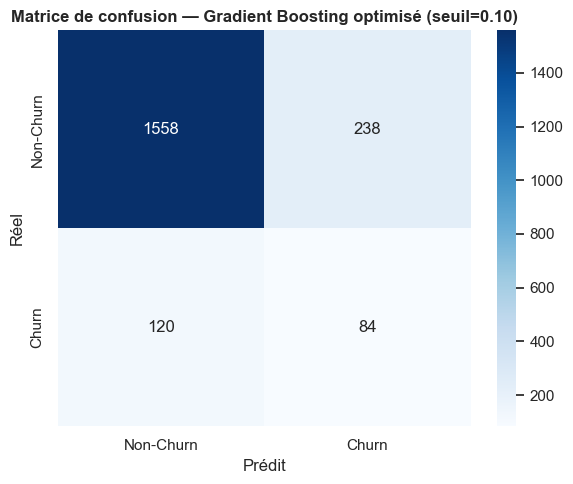

Vrais négatifs  (TN) : 1558
Faux positifs   (FP) : 238 — fausses alertes (clients retenus inutilement ciblés)
Faux négatifs   (FN) : 120 — churners manqués (le plus coûteux business)
Vrais positifs  (TP) : 84


In [13]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_opt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — Gradient Boosting optimisé (seuil={optimal_threshold:.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais négatifs  (TN) : {tn}')
print(f'Faux positifs   (FP) : {fp} — fausses alertes (clients retenus inutilement ciblés)')
print(f'Faux négatifs   (FN) : {fn} — churners manqués (le plus coûteux business)')
print(f'Vrais positifs  (TP) : {tp}')

In [14]:
# Analyser les faux négatifs : quels profils de churners sont manqués ?
test_df = X_test.copy()
test_df['churn_real'] = y_test.values
test_df['churn_pred'] = y_pred_opt
test_df['churn_proba'] = y_proba_opt

fn_mask = (test_df['churn_real'] == 1) & (test_df['churn_pred'] == 0)
fp_mask = (test_df['churn_real'] == 0) & (test_df['churn_pred'] == 1)

print(f'=== Faux négatifs ({fn_mask.sum()} churners manqués) ===')
print('Profil moyen des churners manqués vs churners détectés :')
tp_mask = (test_df['churn_real'] == 1) & (test_df['churn_pred'] == 1)
compare_cols = ['tenure_months', 'monthly_logins', 'payment_failures', 'csat_score', 'support_tickets', 'churn_proba']
compare = pd.DataFrame({
    'FN (manqués)': test_df.loc[fn_mask, compare_cols].mean(),
    'TP (détectés)': test_df.loc[tp_mask, compare_cols].mean(),
}).round(2)
print(compare)

print(f'\n=== Faux positifs ({fp_mask.sum()} fausses alertes) ===')
print('Ces clients non-churners ont des profils proches des churners :')
print(test_df.loc[fp_mask, compare_cols].describe().round(2))

=== Faux négatifs (120 churners manqués) ===
Profil moyen des churners manqués vs churners détectés :
                  FN (manqués)  TP (détectés)
tenure_months            24.57          20.14
monthly_logins           17.64          13.73
payment_failures          0.72           0.86
csat_score                3.32           2.88
support_tickets           1.19           1.15
churn_proba               0.04           0.25

=== Faux positifs (238 fausses alertes) ===
Ces clients non-churners ont des profils proches des churners :
       tenure_months  monthly_logins  payment_failures  csat_score  \
count         238.00          238.00            238.00      238.00   
mean           24.45           16.06              0.64        2.91   
std            18.86           10.63              0.88        1.14   
min             1.00            0.00              0.00        1.00   
25%             5.00            6.25              0.00        2.00   
50%            22.50           17.00           

## 11. Feature Importance

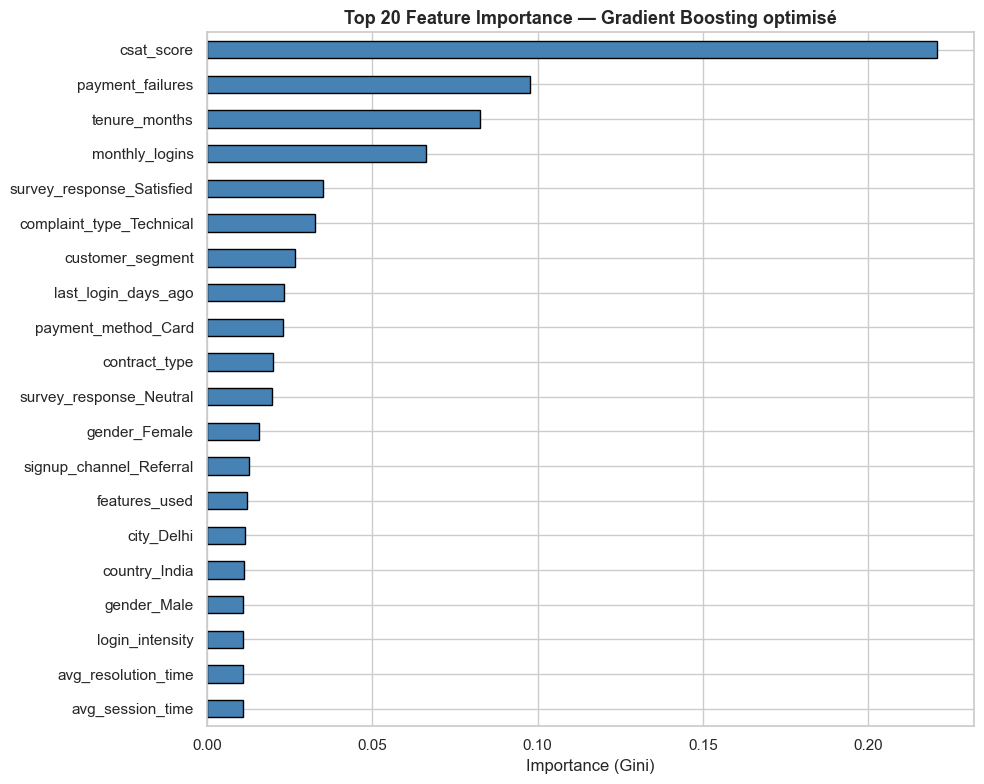

In [15]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Top 20
top20 = feat_imp.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Top 20 Feature Importance — Gradient Boosting optimisé', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}feature_importance.png', bbox_inches='tight')
plt.show()

## 12. SHAP — Interprétabilité du modèle final

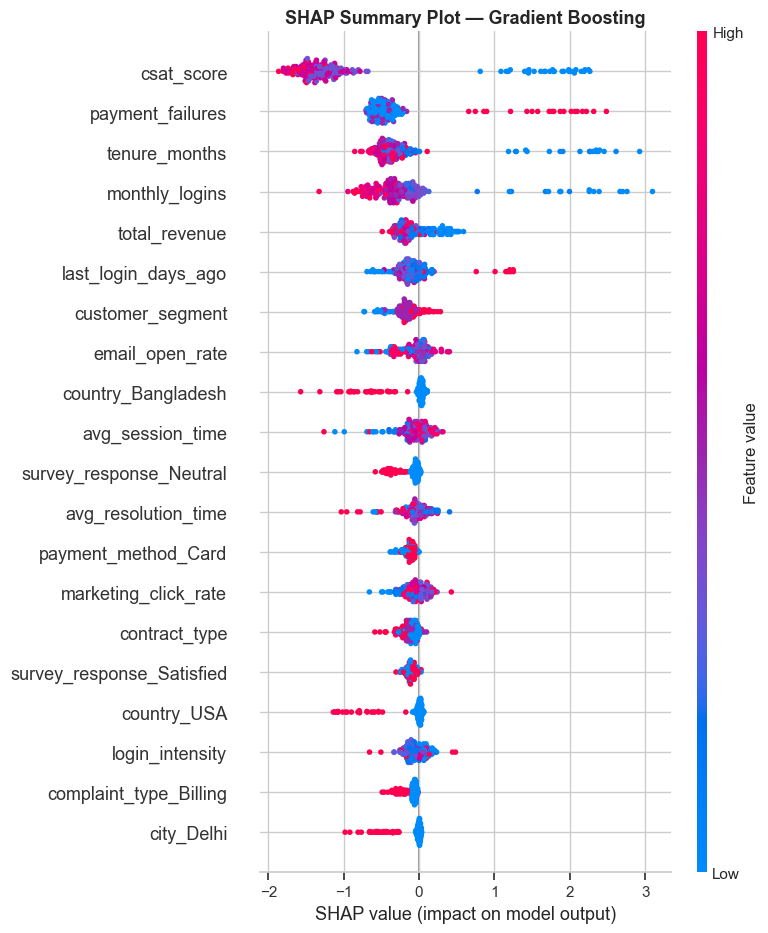

In [16]:
import shap

explainer = shap.TreeExplainer(best_model)
# Utiliser un échantillon pour la performance
X_test_sample = X_test_t[:200]
shap_values = explainer.shap_values(X_test_sample)

# Summary plot
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot — Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

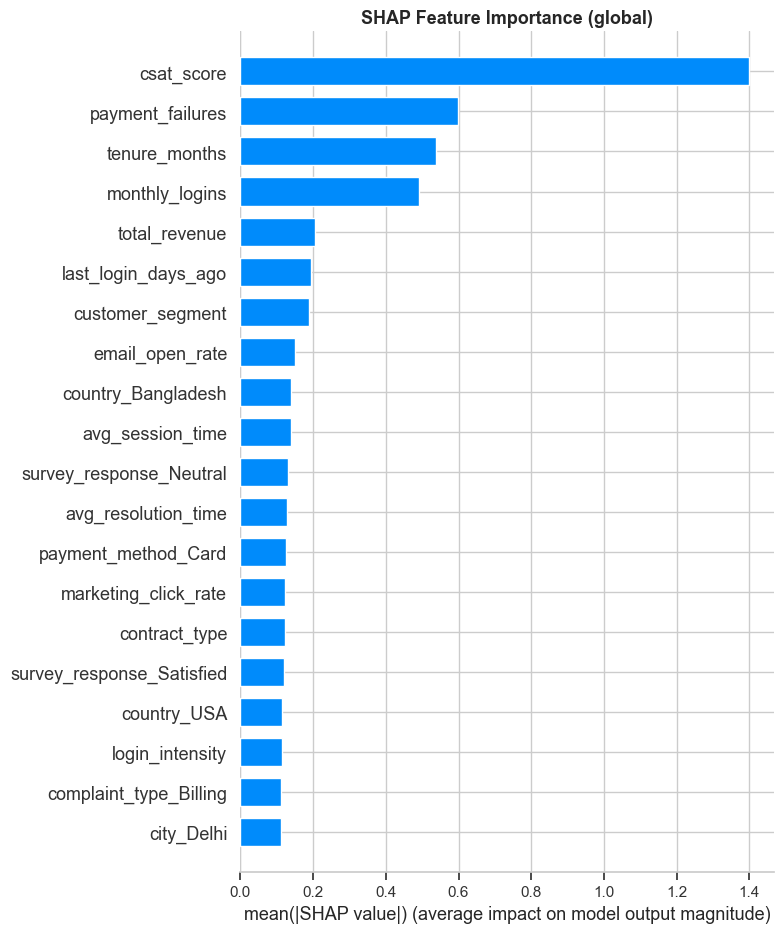

In [17]:
# SHAP bar plot (importance globale)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (global)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. Sélection et sérialisation du modèle final

### Justification du choix

| Critère | Logistic Reg. | Random Forest | Gradient Boosting |
|---------|:---:|:---:|:---:|
| ROC-AUC | Moyen | Bon | **Meilleur** |
| PR-AUC | Moyen | Bon | **Meilleur** |
| Stabilité (CV) | Stable | Stable | **Stable** |
| Interprétabilité | Très bonne | Bonne | **Bonne** (SHAP) |
| Seuil ajustable | Oui | Oui | **Oui** |

**Modèle retenu : Gradient Boosting (optimisé) + SMOTE + seuil ajusté**

Raisons :
1. Meilleur compromis ROC-AUC / PR-AUC
2. Feature importance native + SHAP compatible (interprétabilité)
3. Stable en cross-validation
4. Le seuil permet d'ajuster le compromis Recall/Precision selon le besoin métier

In [18]:
# Sauvegarder le modèle final, le preprocessor, le seuil, les feature names et les métriques
joblib.dump(best_model, f'{ARTIFACTS_DIR}model.joblib')
joblib.dump(preprocessor, f'{ARTIFACTS_DIR}preprocessor.joblib')

with open(f'{ARTIFACTS_DIR}threshold.json', 'w') as f:
    json.dump({'threshold': optimal_threshold}, f)

with open(f'{ARTIFACTS_DIR}feature_names.json', 'w') as f:
    json.dump(feature_names, f)

# Sauvegarder les métriques comparatives (utile pour le dashboard)
all_metrics = metrics_df.to_dict(orient='index')
all_metrics['_best_model'] = 'Gradient Boosting'
all_metrics['_threshold'] = optimal_threshold
all_metrics['_best_params'] = search.best_params_

with open(f'{ARTIFACTS_DIR}metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2, default=str)

# Sauvegarder les splits pour reproductibilité
np.save(f'{ARTIFACTS_DIR}X_train.npy', X_train_t)
np.save(f'{ARTIFACTS_DIR}X_test.npy', X_test_t)
np.save(f'{ARTIFACTS_DIR}y_train.npy', y_train.values)
np.save(f'{ARTIFACTS_DIR}y_test.npy', y_test.values)

print('Artifacts sauvegardés :')
print(f'  model.joblib         — {type(best_model).__name__}')
print(f'  preprocessor.joblib  — ColumnTransformer')
print(f'  threshold.json       — {optimal_threshold:.2f}')
print(f'  feature_names.json   — {len(feature_names)} features')
print(f'  metrics.json         — métriques des 3 modèles')
print(f'  X_train/test.npy, y_train/test.npy')

Artifacts sauvegardés :
  model.joblib         — GradientBoostingClassifier
  preprocessor.joblib  — ColumnTransformer
  threshold.json       — 0.10
  feature_names.json   — 57 features
  metrics.json         — métriques des 3 modèles
  X_train/test.npy, y_train/test.npy


## 14. Synthèse Phase 3

| Étape | Résultat |
|-------|----------|
| **3 modèles** | LogReg (baseline), RF, GB |
| **Déséquilibre** | SMOTE + class_weight + seuil optimal |
| **Meilleur modèle** | Gradient Boosting (optimisé) |
| **Seuil optimal** | Ajusté pour maximiser F1 |
| **Cross-validation** | 5-fold stratifié, stabilité vérifiée |
| **Interprétabilité** | Feature Importance + SHAP |
| **Artifacts** | model.joblib, preprocessor.joblib, threshold.json, metrics.json |

### Discussion des limites
- Les corrélations avec le churn sont faibles (max |r| ≈ 0.16) → le signal est difficile à capter
- Le dataset est synthétique, les performances seraient potentiellement meilleures sur des données réelles avec des patterns plus marqués
- Le compromis Recall/Precision dépend du contexte métier : le seuil pourrait être ajusté par le CRM

### Prochaines étapes
- Brancher le modèle sur l'API `/predict` (Tâche E)
- Intégrer les figures dans le dashboard (Tâche D)